# SLCP 

**Discplaimer**: This example is fairly compute-intensive.

In the following, we demonstrate several `sbijax` methods using the complex "Simple Likelihood Complex Posterior" model.

In [1]:
import jax
import optax
import os
import sbijax
import seaborn as sns

%matplotlib inline
import matplotlib.pyplot as plt

from matplotlib.ticker import AutoLocator, MaxNLocator
from jax import numpy as jnp, random as jr
from tensorflow_probability.substrates.jax import distributions as tfd

We remove some warnings that TFP is emitting, when using 64-bit arithmetic instead of 32-bit.

In [2]:
import warnings

warnings.filterwarnings("ignore")

We implement a custom function to visualize posterior pairs.

In [3]:
def plot_posteriors(obj):
  cmap = sns.color_palette("rocket", as_cmap=False, desat=0.6, n_colors=10)
  cmap = sns.blend_palette(cmap, as_cmap=True)

  _, axes = plt.subplots(figsize=(6, 6), nrows=5, ncols=5)
  for i in range(0, 5):
    for j in range(0, 5):
      ax = axes[i, j]
      if i < j:
        ax.axis("off")
      else:
        ax.hexbin(obj[..., j], obj[..., i], gridsize=50, bins="log", cmap=cmap)
      ax.spines.left.set_linewidth(0.5)
      ax.spines.bottom.set_linewidth(0.5)
      ax.spines.right.set_linewidth(0.5)
      ax.spines.top.set_linewidth(0.5)
      ax.xaxis.set_major_locator(MaxNLocator(2))
      ax.yaxis.set_major_locator(MaxNLocator(2))
      if i != j:
        ax.set_yticks([-3, 0, 3])
        ax.set_xticks([-3, 0, 3])
      else:
        ax.set_yticklabels([])
      if i < 4:
        ax.set_xticklabels([])
        ax.xaxis.set_tick_params(width=0.0, length=0)
      if j != 0:
        ax.set_yticklabels([])
        ax.yaxis.set_tick_params(width=0.0, length=0)
      ax.grid(which="major", axis="both", alpha=0.5)
  for i in range(5):
    axes[i, i].hist(obj[..., i], color="black")
  return axes

In [4]:
def plot_ess_and_trace(samples_arr):
  """Plot trace lines for each parameter across chains."""
  from matplotlib.ticker import AutoLocator

  colors = sns.color_palette("rocket_r", as_cmap=False, desat=0.6, n_colors=10)
  n_chains, n_draws, n_params = samples_arr.shape
  _, axes = plt.subplots(figsize=(6, 2 * n_params), nrows=n_params, ncols=1)
  axes = list(axes)
  for i, ax in enumerate(axes):
    for j in range(n_chains):
      ax.plot(
        samples_arr[j, :, i], color=colors[j % len(colors)], alpha=0.4, lw=0.8
      )
    ax.set_ylabel(rf"$\theta_{i}$", fontsize=13)
    ax.spines[["right", "top"]].set_visible(False)
    ax.yaxis.set_major_locator(AutoLocator())
  axes[-1].set_xlabel("draw", fontsize=13)
  plt.tight_layout()
  return axes

We then define the generative model. This is the standard SLCP ("simple likelihood, complex posterior") benchmark: the 5 raw parameters are reparametrized into two means, two (squared, so positive) standard deviations and a `tanh`-bounded correlation, which together define a 2-D Gaussian. The simulator draws 4 i.i.d. samples from that Gaussian and flattens them into the 8-D observation `y`. The likelihood is Gaussian and simple, but the nonlinear reparametrization gives the posterior over the raw parameters a non-trivial, multimodal shape — hence "complex posterior".

In [5]:
def prior_fn():
  prior = tfd.JointDistributionNamed(
    dict(theta=tfd.Uniform(jnp.full(5, -3.0), jnp.full(5, 3.0))), batch_ndims=0
  )
  return prior


def simulator_fn(seed, theta):
  theta = theta["theta"]
  theta = theta[:, None, :]
  us_key, noise_key = jr.split(seed)

  def _unpack_params(ps):
    m0 = ps[..., [0]]
    m1 = ps[..., [1]]
    s0 = ps[..., [2]] ** 2
    s1 = ps[..., [3]] ** 2
    r = jnp.tanh(ps[..., [4]])
    return m0, m1, s0, s1, r

  m0, m1, s0, s1, r = _unpack_params(theta)
  us = tfd.Normal(0.0, 1.0).sample(
    seed=us_key, sample_shape=(theta.shape[0], theta.shape[1], 4, 2)
  )
  xs = jnp.empty_like(us)
  xs = xs.at[:, :, :, 0].set(s0 * us[:, :, :, 0] + m0)
  y = xs.at[:, :, :, 1].set(
    s1 * (r * us[:, :, :, 0] + jnp.sqrt(1.0 - r**2) * us[:, :, :, 1]) + m1
  )
  y = y.reshape((*theta.shape[:1], 8))
  return y

We fix the observation to a specific value from the literature that induces an exciting posterior geometry.

In [6]:
y_obs = jnp.array(
  [
    [
      -0.9707123,
      -2.9461224,
      -0.4494722,
      -3.4231849,
      -0.13285634,
      -3.364017,
      -0.85367596,
      -2.4271638,
    ]
  ]
)

It is 8-dimensional because the simulator returns 4 i.i.d. draws from the 2-D Gaussian, flattened. Note the leading axis of size 1: observations are passed batched, so a single observation has shape `(1, 8)` rather than `(8,)`.

### MCMC

We first sample from the "true" posterior using MCMC, specifically a slice sampler.

The simulator has a closed-form likelihood, so we can also sample the (ground-truth) posterior directly with MCMC. This is not something the neural methods below get to use — they only see `(theta, y)` pairs from the simulator — but it gives us a ground-truth posterior to compare their output against.

In [7]:
from functools import partial
from jax import scipy as jsp
from sbijax.mcmc import sample_with_nuts, sample_with_slice

In [8]:
def likelihood_fn(theta, y):
  mu = jnp.tile(theta[:2], 4)
  s1, s2 = theta[2] ** 2, theta[3] ** 2
  corr = s1 * s2 * jnp.tanh(theta[4])
  cov = jnp.array([[s1**2, corr], [corr, s2**2]])
  cov = jsp.linalg.block_diag(*[cov for _ in range(4)])
  p = tfd.MultivariateNormalFullCovariance(mu, cov)
  return p.log_prob(y)


def log_density_fn(theta, y):
  prior_lp = tfd.JointDistributionNamed(
    dict(theta=tfd.Uniform(jnp.full(5, -3.0), jnp.full(5, 3.0)))
  ).log_prob(theta)
  likelihood_lp = likelihood_fn(theta, y)
  lp = jnp.sum(prior_lp) + jnp.sum(likelihood_lp)
  return lp

Two things are worth noting in `likelihood_fn`: The 4 i.i.d. draws are handled by tiling the mean and building a block-diagonal covariance, so the 8-D observation is treated as one 8-D Gaussian with a repeating 2×2 block. And `theta[2]` and `theta[3]` enter only through their squares which is exactly what makes this posterior interesting, as the plot below shows.

A slice sampler is used rather than NUTS here: the target is multimodal which is typically a complex geometry to explore for gradient-based samplers like NUTS.

In [9]:
log_density = partial(log_density_fn, y=y_obs)


def lp(theta):
  return log_density(theta["theta"])


slice_samples_raw, _ = sample_with_slice(
  jr.key(0), lp, prior_fn(), n_chains=10, n_samples=10_000, n_warmup=5_000
)
slice_samples = slice_samples_raw["theta"]

We then compute model diagnostics.


In [10]:
slice_samples_dict = {"theta": slice_samples.reshape(10, 5000, 5)}
print("ESS:", sbijax.ess(slice_samples_dict))
print("R-hat:", sbijax.rhat(slice_samples_dict))

ESS: {'theta': Array([49247.61 , 45751.457, 34526.8  , 37308.582, 52743.375], dtype=float32)}
R-hat: {'theta': Array([1.0031444, 1.0033463, 1.0376533, 1.0050069, 1.0019763], dtype=float32)}


R-hat is essentially 1.0 for all five parameters and the effective sample sizes are in the tens of thousands, so the chains have mixed and these draws are a trustworthy reference posterior.

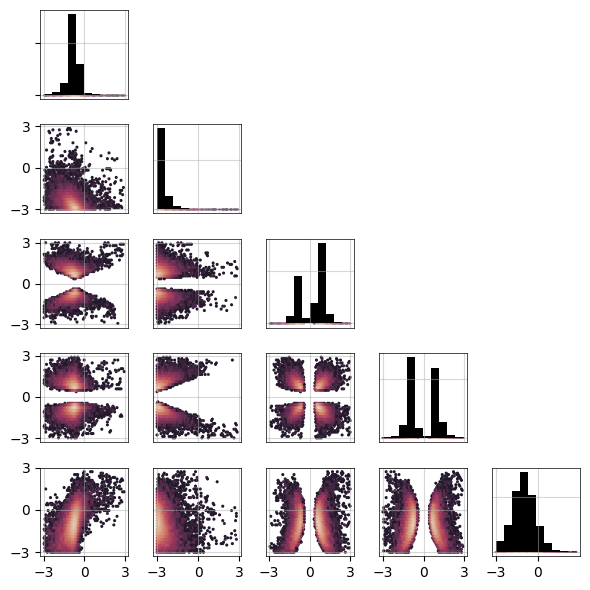

In [11]:
plot_posteriors(slice_samples.reshape(-1, 5))
plt.tight_layout()
plt.show()

This is the reference posterior, and it shows where the "complex posterior" in the name comes from. The $\theta_0$ and $\theta_1$ marginals are simple and unimodal, but $\theta_2$ and $\theta_3$ are each symmetric about zero, and their joint panel shows four separate blobs.

The reason is exact, not an artifact of sampling: the simulator uses `s0 = theta[2] ** 2` and `s1 = theta[3] ** 2`, so flipping the sign of either parameter leaves the likelihood completely unchanged. Every posterior mode therefore has three mirror images — $(\pm\theta_2, \pm\theta_3)$ — all with identical density. $\theta_4$ enters through `tanh`, which is monotone, so it adds no further symmetry.

This is a hard target to recover: a method has to find all four modes, not just one. Keep this plot in mind as the benchmark for the three methods below.

### SNLE

Next, we use surjective neural likelihood estimation to compute a posterior distribution.

SNLE learns the *likelihood*: a conditional density $q_\phi(y \mid \theta)$ trained to approximate $p(y \mid \theta)$, using the simulated pairs as training data. The objective is plain maximum likelihood — the loss is $-\frac{1}{n}\sum_i \log q_\phi(y_i \mid \theta_i)$ — which is available in closed form because the model is a normalizing flow.

The posterior is never learned. It is assembled only at sampling time, by giving MCMC the unnormalized target

$$q_\phi(y_{\text{obs}} \mid \theta)\, p(\theta) \;\propto\; p(\theta \mid y_{\text{obs}}),$$

so the learned likelihood supplies one factor and the prior supplies the other. This is why `sample` below needs a `sampler` argument, and why the result depends on the sampler mixing well as well as on the flow fitting well.

In [12]:
from sbijax import run_sequential, sample, snle
from sbijax.mcmc import make_sampler, nuts
from sbijax.nn import make_maf

In [13]:
n_dim_data = 8
n_layer_dimensions, hidden_sizes = (8, 8, 5, 5, 5), (64, 64)
neural_network = make_maf(
  n_dim_data, n_layer_dimensions=n_layer_dimensions, hidden_sizes=hidden_sizes
)

prior = prior_fn()
model_snle = snle(neural_network)

`n_layer_dimensions=(8, 8, 5, 5, 5)` is what makes this flow *surjective*: the first two layers preserve all 8 dimensions of `y`, then a dimensionality-reducing layer funnels down to 5 — matching `theta`'s dimensionality — and the remaining layers operate at that reduced size. The funnel layer contributes an extra likelihood-contribution term rather than an exact log-det, which is what lets the flow model a lower-dimensional density than its input.

In [14]:
snle_params, info = run_sequential(
  jr.key(1),
  model_snle,
  prior,
  simulator_fn,
  y_obs,
  n_rounds=15,
  n_simulations_per_round=1_000,
  sampler=make_sampler(nuts, prior=prior),
)

 12%|███▊                           | 123/1000 [01:27<10:20,  1.41it/s]


SNLE is trained sequentially here (`n_rounds=15`) rather than amortized on a single large simulation batch: each round simulates from the posterior fit in the previous round rather than the prior, concentrating the simulation budget on parameter regions consistent with `y_obs` instead of spreading it uniformly over the whole prior.

In [15]:
snle_samples, _ = sample(
  jr.key(5),
  model_snle,
  snle_params,
  y_obs,
  sampler=make_sampler(nuts, prior=prior),
  n_samples=5_000,
  n_warmup=2_500,
  n_chains=10,
)

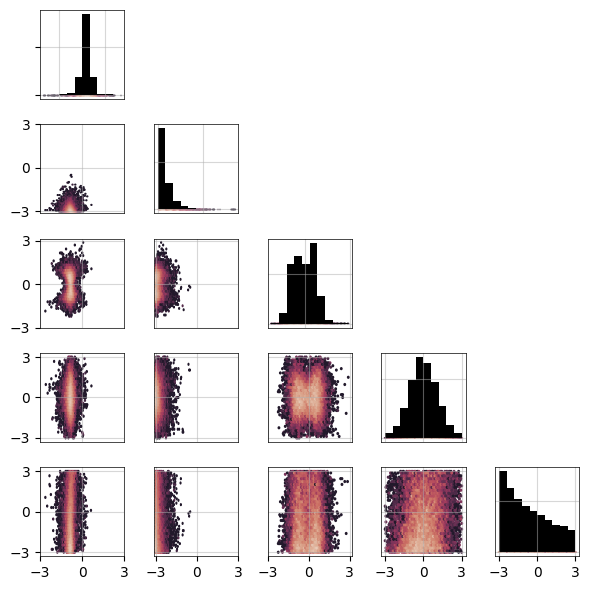

In [16]:
plot_posteriors(
  snle_samples["theta"].reshape(-1, 5),
)
plt.tight_layout()
plt.show()

Compare this against the reference posterior above. SNLE never sees the analytic likelihood — it learns one from simulations — and then hands that learned likelihood to NUTS, so the quality of the result depends both on how well the flow fits and on how well the sampler explores it.

### FMPE

As a comparison, we use flow matching posterior estimation. FMPE takes the opposite approach to SNLE: instead of learning the likelihood $p(y \mid \theta)$ and handing it to a sampler, it learns the posterior $p(\theta \mid y)$ directly, so no MCMC is involved at any point.

The model is a continuous normalizing flow. Rather than a stack of invertible layers, it learns a time-dependent vector field that transports a standard normal at $t=0$ into the posterior at $t=1$, conditioned on the observation.

In [17]:
from sbijax import fmpe, sample, simulate, train
from sbijax.nn import make_cnf

In [18]:
n_dim_theta = 5
n_layers, hidden_size = 5, 128
neural_network = make_cnf(n_dim_theta, n_layers, hidden_size)

model_fmpe = fmpe(neural_network)

Note the dimensionality, and contrast it with SNLE above. There the network was built with `n_dim_data = 8`, because SNLE models the *data*. Here it is `n_dim_theta = 5`, because FMPE models the *parameters*. That single number is the clearest expression of the difference between the two approaches — and it is why FMPE needs no surjective funnel layers: the flow already lives in the 5-dimensional parameter space rather than having to be squeezed down into it from 8 dimensions.

The observation enters as conditioning information (the `context`) instead of being the thing that is modelled.

In [19]:
data = simulate(
  jr.key(1),
  prior,
  simulator_fn,
  n=20_000,
)
fmpe_params, info = train(
  jr.key(2),
  model_fmpe,
  data,
  optimizer=optax.adam(0.001),
  n_early_stopping_delta=0.00001,
  n_early_stopping_patience=30,
)

  6%|█▉                              | 62/1000 [01:12<18:20,  1.17s/it]


All 20,000 simulations are drawn from the prior in one go — there are no rounds here, unlike SNLE's 15. Training regresses the network onto the target vector field: a time $t \sim U(0, 1)$ is drawn per example, the parameter is interpolated between noise and its true value at that time, and the loss is the mean squared error between the predicted and the true velocity. It is a plain regression objective, with no likelihood evaluated and no normalizing constant needed.

`n_early_stopping_delta=0.00001` is set unusually tight because that MSE keeps improving in small increments; with the default the run would stop while the flow is still sharpening.

In [20]:
fmpe_samples, _ = sample(
  jr.key(5), model_fmpe, fmpe_params, y_obs, n_samples=25_000
)

Unlike SNLE, `sample` takes no `sampler` here: FMPE models the posterior directly, so there is no MCMC — no chains, no warmup, no accept/reject step, and nothing to check for convergence.

Sampling instead draws 25,000 points from the standard normal base distribution and integrates the learned vector field from $t=0$ to $t=1$. That integration is done with an adaptive RK45 solver, so it evaluates the network many times per draw rather than once, but it is deterministic given the initial noise and all draws are independent.

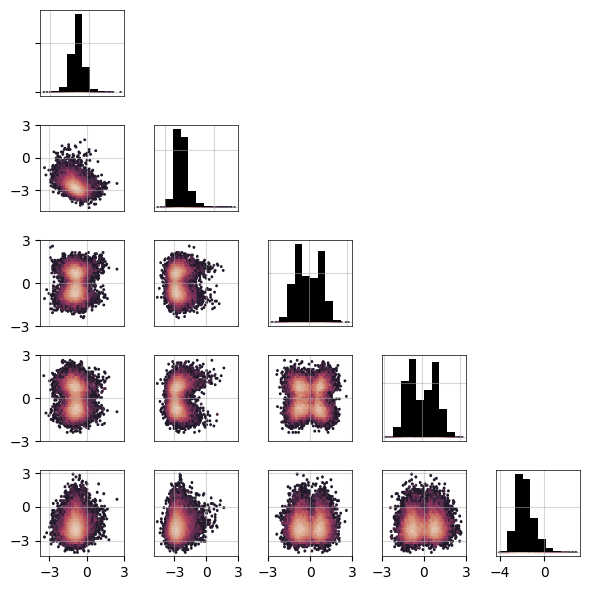

In [21]:
plot_posteriors(
  fmpe_samples["theta"].reshape(-1, 5),
)
plt.tight_layout()
plt.show()

Compare this against the reference posterior above, and against SNLE's.

FMPE was trained amortized on a single batch of 20,000 prior simulations, so — unlike SNLE — it was never steered toward `y_obs` during training. That cuts both ways. The fitted network is reusable: posterior draws for a *different* observation cost only another ODE integration, with no retraining and no new simulations, whereas SNLE's sequential rounds are tied to the `y_obs` they were run for. But the simulation budget was spread uniformly over the whole prior instead of concentrated where the data actually points, so for this one observation SNLE gets more out of each simulation.

### SMC-ABC

Finally, we evaluate SMC-ABC using neural sufficient statistics.

ABC learns no density at all — neither $p(y \mid \theta)$ like SNLE nor $p(\theta \mid y)$ like FMPE. It only ever *runs* the simulator, and accepts a parameter when the data it produces looks close enough to the observation. The distribution it targets is therefore not the posterior itself but

$$p_\epsilon(\theta \mid y_{\text{obs}}) \;\propto\; p(\theta)\, \Pr\big(\, d(s(y), s(y_{\text{obs}})) < \epsilon \;\big|\; \theta \,\big), \qquad y \sim p(y \mid \theta),$$

that is, the posterior given that a summary statistic $s$ falls within a tolerance $\epsilon$ of the observed one, rather than given $y_{\text{obs}}$ exactly.

This introduces two approximations that the two neural methods above do not have. The tolerance $\epsilon$ is greater than zero, so the conditioning event is a neighbourhood rather than a point — exactness is recovered only as $\epsilon \to 0$, which costs an ever-growing number of simulations. And the comparison happens through $s$, so any information $s$ discards is lost: equality holds only if $s$ is sufficient. Choosing a good $s$ is exactly what the next cells are about.

The raw 8-D `y` is a poor choice for $s$: Euclidean distance in data space does not track parameter similarity well, so a small $d$ would not imply a good $\theta$. NASS instead *learns* $s$, mapping the data to a lower-dimensional embedding (here `n_embedding_dim=5`) by maximizing a mutual-information bound between summaries and parameters — pushing $s$ toward sufficiency, which is the condition under which the $\epsilon \to 0$ limit above recovers the true posterior.

Note that this is the one place ABC does train a network. It is used only to define the distance, though — the inference itself still evaluates no density.

In [22]:
from sbijax import nass, simulate, smcabc, train
from sbijax.nn import make_nass_net

In [23]:
n_embedding_dim, hidden_sizes = 5, (64, 64)
neural_network = make_nass_net(n_embedding_dim, hidden_sizes)

model_nass = nass(neural_network)

data = simulate(jr.key(1), prior, simulator_fn, n=20_000)
params_nass, _ = train(
  jr.key(2), model_nass, data, n_early_stopping_patience=25
)

 14%|████▍                          | 145/1000 [02:03<12:10,  1.17it/s]


In [24]:
def summary_fn(y):
  s = model_nass.summarize_fn(params_nass, y)
  return s


def distance_fn(y_simulated, y_observed):
  diff = y_simulated - y_observed
  dist = jax.vmap(lambda el: jnp.linalg.norm(el))(diff)
  return dist

In [25]:
model_smc = smcabc(prior, simulator_fn, summary_fn, distance_fn)

smc_samples, _ = model_smc.sample(
  jr.key(5),
  y_obs,
  n_rounds=10,
  n_particles=5_000,
  eps_step=0.9,
  ess_min=2_000,
)

100%|██████████████████████████████████| 10/10 [07:53<00:00, 47.38s/it]


This is the sequential Monte Carlo part, which exists to make the $\epsilon \to 0$ limit affordable. Sampling directly at a small $\epsilon$ would reject almost every draw, so SMC instead starts from a loose tolerance and tightens it gradually, carrying a population of 5,000 particles from one round to the next.

`eps_step=0.9` shrinks $\epsilon$ by 10% per round over 10 rounds, and a particle is kept when its simulated distance falls below the current $\epsilon$. Particles are reweighted by $p(\theta)$ divided by the density of the proposal that produced them, and `ess_min=2_000` triggers resampling whenever the effective sample size of those weights drops below 2,000 — without it, weight would concentrate on a handful of particles and the population would collapse.

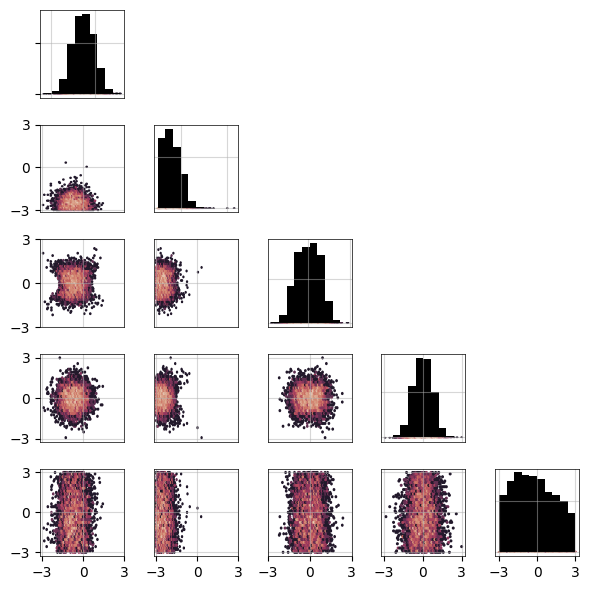

In [26]:
plot_posteriors(
  smc_samples["theta"].reshape(-1, 5),
)
plt.tight_layout()
plt.show()

These draws come from $p_\epsilon(\theta \mid y_{\text{obs}})$ at the final tolerance, not from the posterior itself, so they are typically broader than the reference — the residual width is the price of $\epsilon > 0$.

The three methods differ in what they learn. SNLE learns $p(y \mid \theta)$ and needs MCMC to turn it into a posterior. FMPE learns $p(\theta \mid y)$ directly and needs no sampler, at the cost of training amortized over the whole prior. ABC learns nothing and only calls the simulator, which is what makes it applicable when no density can be written down at all — but it is the only one of the three whose target is not the exact posterior even in the limit of infinite compute, unless the summary statistic happens to be sufficient.

## Session info

In [27]:
import session_info

session_info.show(html=False)

-----
haiku                       0.0.17
jax                         0.11.1
jaxlib                      0.11.1
matplotlib                  3.10.8
optax                       0.2.8
sbijax                      0.4.0
seaborn                     0.13.2
session_info                v1.0.1
tensorflow_probability      0.26.0-dev20260318
-----
IPython             9.11.0
jupyter_client      8.8.0
jupyter_core        5.9.1
jupyterlab          4.5.6
notebook            7.5.5
-----
Python 3.12.10 (main, May 30 2025, 05:53:56) [Clang 20.1.4 ]
macOS-26.2-arm64-arm-64bit
-----
Session information updated at 2026-09-10 20:42
